# Predictive Analysis Project
**Dataset:** NYC Green Taxi Trips — September 2023  
**Dependent Variable:** `total_amount`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

## a) Import Parquet File

In [2]:
df = pd.read_parquet("C:\\Users\\divya\\Downloads\\green_tripdata_2023-09.parquet")

## b) Info(), Head(), Tail()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65471 entries, 0 to 65470
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               65471 non-null  int32         
 1   lpep_pickup_datetime   65471 non-null  datetime64[us]
 2   lpep_dropoff_datetime  65471 non-null  datetime64[us]
 3   store_and_fwd_flag     60856 non-null  object        
 4   RatecodeID             60856 non-null  float64       
 5   PULocationID           65471 non-null  int32         
 6   DOLocationID           65471 non-null  int32         
 7   passenger_count        60856 non-null  float64       
 8   trip_distance          65471 non-null  float64       
 9   fare_amount            65471 non-null  float64       
 10  extra                  65471 non-null  float64       
 11  mta_tax                65471 non-null  float64       
 12  tip_amount             65471 non-null  float64       
 13  t

In [4]:
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,1,2023-09-01 00:08:04,2023-09-01 00:13:39,N,1.0,41,75,1.0,1.10,7.9,1.00,1.5,0.00,0.0,NaN,1.0,10.4,1.0,1.0,0.00
1,1,2023-09-01 00:30:44,2023-09-01 00:39:30,N,1.0,74,236,1.0,1.80,10.7,3.75,1.5,3.15,0.0,NaN,1.0,19.1,1.0,1.0,2.75
2,2,2023-09-01 00:14:39,2023-09-01 00:38:30,N,5.0,93,205,2.0,10.52,60.0,0.00,0.0,0.00,0.0,NaN,1.0,61.0,1.0,2.0,0.00
3,2,2023-09-01 00:35:48,2023-09-01 00:56:48,N,1.0,112,17,1.0,4.72,23.3,1.00,0.5,10.00,0.0,NaN,1.0,35.8,1.0,1.0,0.00
4,2,2023-09-01 00:32:03,2023-09-01 00:43:11,N,1.0,131,82,1.0,5.95,24.0,1.00,0.5,0.00,0.0,NaN,1.0,26.5,2.0,1.0,0.00


In [5]:
df.tail()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
65466,2,2023-09-30 22:09:00,2023-09-30 22:21:00,None,NaN,17,35,NaN,2.19,12.53,0.0,0.0,2.44,0.00,NaN,1.0,15.97,NaN,NaN,NaN
65467,2,2023-09-30 22:06:00,2023-09-30 22:15:00,None,NaN,166,244,NaN,2.51,15.88,0.0,0.0,3.38,0.00,NaN,1.0,20.26,NaN,NaN,NaN
65468,2,2023-09-30 22:02:00,2023-09-30 22:38:00,None,NaN,166,132,NaN,6452.20,57.05,0.0,0.0,9.75,6.94,NaN,1.0,74.74,NaN,NaN,NaN
65469,2,2023-09-30 23:22:00,2023-09-30 23:38:00,None,NaN,159,137,NaN,7.39,29.61,0.0,0.0,0.00,0.00,NaN,1.0,33.36,NaN,NaN,NaN
65470,2,2023-09-30 23:17:00,2023-09-30 23:42:00,None,NaN,66,61,NaN,3.64,24.25,0.0,0.0,5.05,0.00,NaN,1.0,30.30,NaN,NaN,NaN


## c) Create trip_duration (dropoff - pickup time in minutes)

In [6]:
df['lpep_pickup_datetime'] = pd.to_datetime(df['lpep_pickup_datetime'])
df['lpep_dropoff_datetime'] = pd.to_datetime(df['lpep_dropoff_datetime'])

df['trip_duration'] = (
    df['lpep_dropoff_datetime'] - df['lpep_pickup_datetime']
).dt.total_seconds() / 60

df[['lpep_pickup_datetime', 'lpep_dropoff_datetime', 'trip_duration']].head()

,lpep_pickup_datetime,lpep_dropoff_datetime,trip_duration
0,2023-09-01 00:08:04,2023-09-01 00:13:39,5.583333
1,2023-09-01 00:30:44,2023-09-01 00:39:30,8.766667
2,2023-09-01 00:14:39,2023-09-01 00:38:30,23.850000
3,2023-09-01 00:35:48,2023-09-01 00:56:48,21.000000
4,2023-09-01 00:32:03,2023-09-01 00:43:11,11.133333


## d) Extract Hour and Weekday from Dropoff Variable

In [7]:
df['hour'] = df['lpep_dropoff_datetime'].dt.hour
df['weekday'] = df['lpep_dropoff_datetime'].dt.day_name()

df[['hour', 'weekday']].head()

,hour,weekday
0,0,Friday
1,0,Friday
2,0,Friday
3,0,Friday
4,0,Friday


## e) Average trip_distance for Different Hour

In [8]:
avg_hour = df.groupby('hour')['trip_distance'].mean()
print(avg_hour)

hour
0       4.851131
1       4.943858
2      43.266777
3      23.812055
4       3.605991
5       3.995155
6      35.023591
7     110.925122
8      15.926658
9      21.957244
10     36.985593
11     19.561935
12     15.799540
13     40.378828
14     74.327671
15     20.869451
16     12.669128
17     14.187526
18     14.052291
19     13.422841
20     25.217143
21      3.884529
22     12.607527
23      4.703752
Name: trip_distance, dtype: float64


## f) Average trip_distance for Different Weekday

In [9]:
avg_weekday = df.groupby('weekday')['trip_distance'].mean()
print(avg_weekday)

weekday
Friday       18.033659
Monday       68.634954
Saturday     12.314393
Sunday       15.715274
Thursday     11.978692
Tuesday      25.387336
Wednesday    24.298276
Name: trip_distance, dtype: float64


## g) Histogram, Boxplot, Density Curve — trip_distance

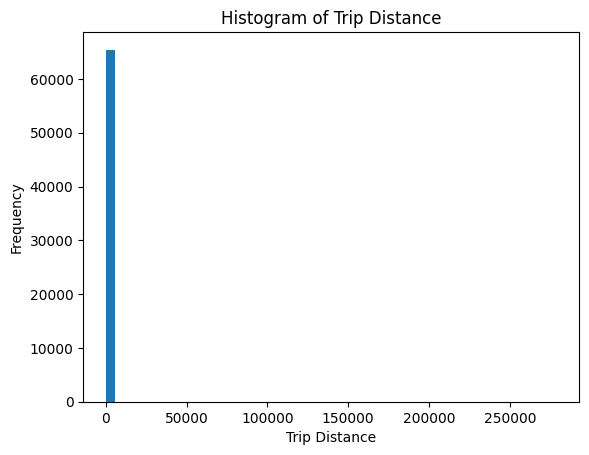

In [10]:
plt.hist(df['trip_distance'], bins=50)
plt.title("Histogram of Trip Distance")
plt.xlabel("Trip Distance")
plt.ylabel("Frequency")
plt.show()

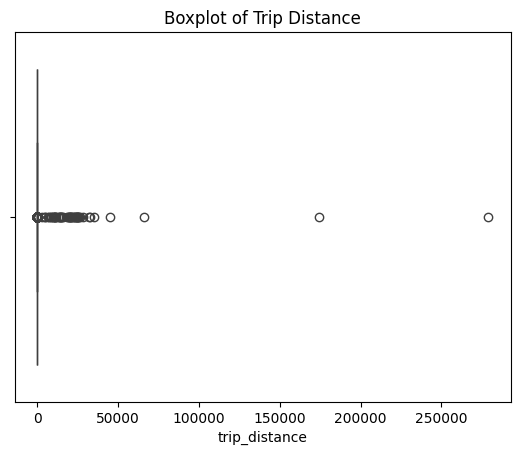

In [11]:
sns.boxplot(x=df['trip_distance'])
plt.title("Boxplot of Trip Distance")
plt.show()

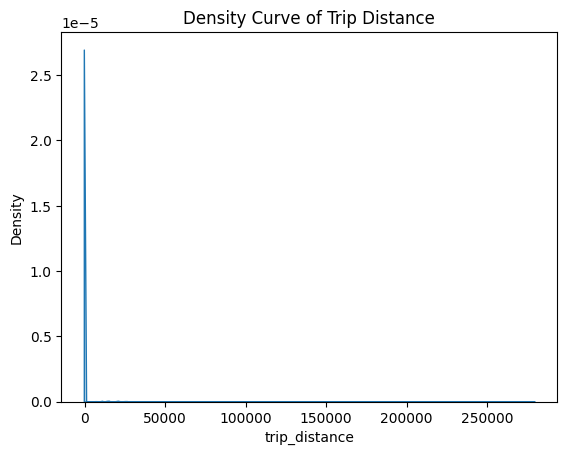

In [12]:
sns.kdeplot(df['trip_distance'], fill=True)
plt.title("Density Curve of Trip Distance")
plt.show()

## h) Categorical / Object Variables

In [13]:
object_cols = [
    'VendorID',
    'store_and_fwd_flag',
    'RatecodeID',
    'payment_type',
    'trip_type',
    'hour',
    'weekday'
]

print("Categorical/Object Columns:")
print(object_cols)

Categorical/Object Columns:
['VendorID', 'store_and_fwd_flag', 'RatecodeID', 'payment_type', 'trip_type', 'hour', 'weekday']


## i) Numeric Columns

In [14]:
num_cols = [
    'passenger_count',
    'trip_distance',
    'fare_amount',
    'extra',
    'mta_tax',
    'tip_amount',
    'tolls_amount',
    'improvement_surcharge',
    'total_amount',
    'congestion_surcharge',
    'cbd_congestion_fee'
]

# Keep only columns that actually exist in the dataframe
num_cols = [col for col in num_cols if col in df.columns]

print("Numeric Columns:")
print(num_cols)

Numeric Columns:
['passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge']


## j) Fill Missing Values

In [15]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop columns that are entirely null
df = df.dropna(axis=1, how='all')

# Refresh num_cols to only include columns still present
num_cols = [col for col in num_cols if col in df.columns]

# Fill missing numeric values with column mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

print("Missing values after filling:")
print(df[num_cols].isnull().sum())

Missing values after filling:
passenger_count          0
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
dtype: int64


## k) Describe() of Numeric Variables

In [16]:
df[num_cols].describe()

,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
count,65471.000000,65471.000000,65471.000000,65471.000000,65471.000000,65471.000000,65471.000000,65471.000000,65471.000000,65471.000000
mean,1.305672,24.532310,20.602176,0.881352,0.560653,2.629762,0.358797,0.986609,26.556307,0.749462
std,0.917873,1419.762707,22.898428,1.365553,0.390091,3.809337,1.645911,0.139077,25.157953,1.180125
min,0.000000,0.000000,-500.000000,-5.000000,-0.500000,-0.900000,0.000000,-1.000000,-501.000000,-2.750000
25%,1.000000,1.170000,10.000000,0.000000,0.500000,0.000000,0.000000,1.000000,13.900000,0.000000
50%,1.000000,2.000000,14.900000,0.000000,0.500000,2.000000,0.000000,1.000000,19.900000,0.000000
75%,1.000000,3.770000,24.000000,1.000000,0.500000,3.830000,0.000000,1.000000,31.000000,2.750000
max,9.000000,278990.280000,1369.400000,7.750000,1.500000,112.000000,40.000000,1.000000,1372.700000,2.750000


## l) Scale Numeric Columns (Except total_amount)

In [17]:
scale_cols = [col for col in num_cols if col != 'total_amount']

scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaled columns:", scale_cols)

Scaled columns: ['passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge']


## m) Correlation Heatmap for Numeric Columns

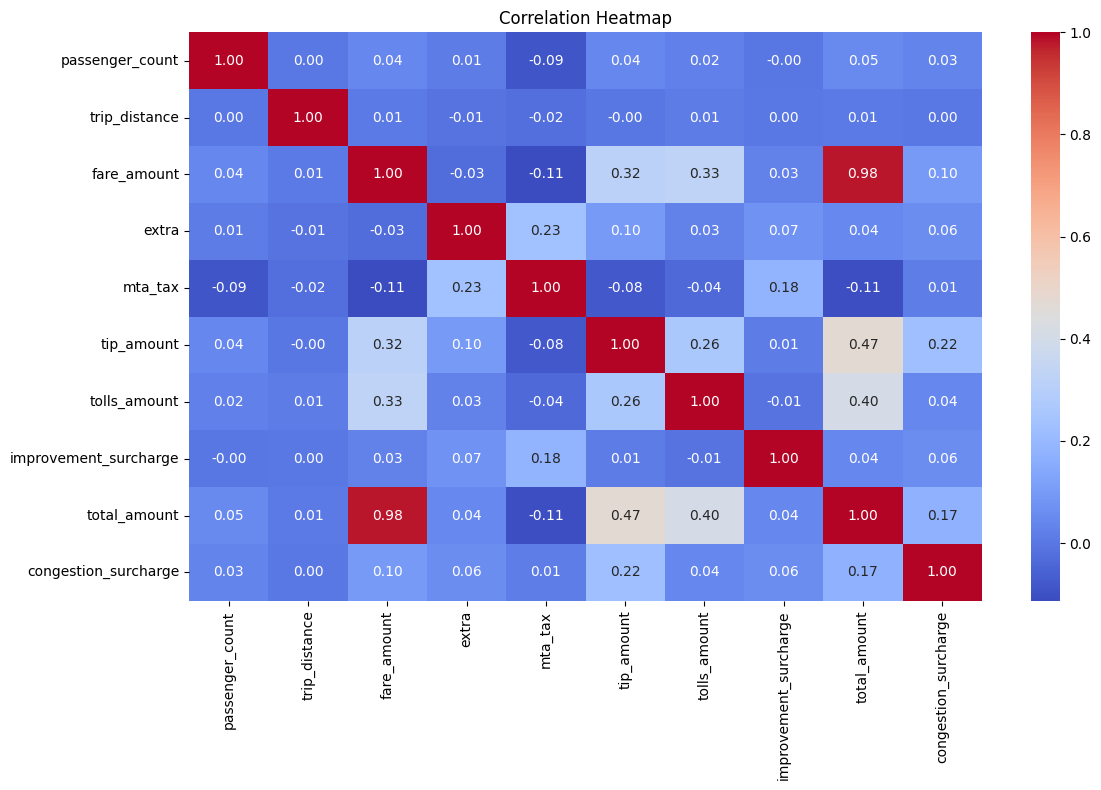

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## n) Value Counts of All Object/Categorical Variables

In [19]:
for col in object_cols:
    if col in df.columns:
        print(f"\nValue counts for '{col}':")
        print(df[col].value_counts())


Value counts for 'VendorID':
VendorID
2    56902
1     8569
Name: count, dtype: int64

Value counts for 'store_and_fwd_flag':
store_and_fwd_flag
N    60592
Y      264
Name: count, dtype: int64

Value counts for 'RatecodeID':
RatecodeID
1.0     57268
5.0      3269
2.0       161
4.0       103
3.0        48
99.0        6
6.0         1
Name: count, dtype: int64

Value counts for 'payment_type':
payment_type
1.0    41240
2.0    18934
3.0      532
4.0      150
Name: count, dtype: int64

Value counts for 'trip_type':
trip_type
1.0    57787
2.0     3063
Name: count, dtype: int64

Value counts for 'hour':
hour
18    5156
17    4991
16    4619
15    4260
19    4059
14    3907
12    3697
10    3440
11    3432
13    3431
20    3350
9     3342
21    2941
8     2669
22    2560
7     2165
23    2023
0     1671
1      998
6      763
2      726
3      477
4      439
5      355
Name: count, dtype: int64

Value counts for 'weekday':
weekday
Friday       11439
Thursday     10132
Wednesday     9755
Saturd

## o) Dummy Encode Object/Categorical Columns

In [20]:
cols_to_encode = [col for col in object_cols if col in df.columns]
df = pd.get_dummies(df, columns=cols_to_encode, drop_first=True)

print("Shape after dummy encoding:", df.shape)

Shape after dummy encoding: (65471, 56)


## p) Build Regression Models
**Dependent Variable:** `total_amount`  
**Independent Variables:** All remaining columns (excluding datetime columns)

In [21]:
# Drop datetime columns, keep all other features
df = df.drop(['lpep_pickup_datetime', 'lpep_dropoff_datetime'], axis=1)

X = df.drop('total_amount', axis=1)
y = df['total_amount']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (52376, 53)
Test size: (13095, 53)


In [22]:
results = {}

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    r2 = r2_score(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    results[name] = {'R2 Score': round(r2, 4), 'RMSE': round(rmse, 4)}
    print(f"{name}")
    print(f"  R2 Score : {r2:.4f}")
    print(f"  RMSE     : {rmse:.4f}")
    print()

### 1. Multiple Linear Regression

In [23]:
evaluate_model("Multiple Linear Regression", LinearRegression())

Multiple Linear Regression
  R2 Score : 0.9996
  RMSE     : 0.5066



### 2. Decision Tree Regression

In [24]:
evaluate_model("Decision Tree Regression", DecisionTreeRegressor())

Decision Tree Regression
  R2 Score : 0.9911
  RMSE     : 2.3275



### 3. Random Forest Regression

In [25]:
evaluate_model("Random Forest Regression", RandomForestRegressor())

Random Forest Regression
  R2 Score : 0.9949
  RMSE     : 1.7602



### 4. Gradient Boosting Regression

In [26]:
evaluate_model("Gradient Boosting Regression", GradientBoostingRegressor())

Gradient Boosting Regression
  R2 Score : 0.9968
  RMSE     : 1.3873



### 5. KNN Regression

In [27]:
evaluate_model("KNN Regression", KNeighborsRegressor())

KNN Regression
  R2 Score : 0.7559
  RMSE     : 12.2012



### 6. Support Vector Regression

In [28]:
evaluate_model("Support Vector Regression", SVR())

Support Vector Regression
  R2 Score : 0.3866
  RMSE     : 19.3413



### 7. MLP Regressor

In [29]:
evaluate_model("MLP Regressor", MLPRegressor(max_iter=500))

MLP Regressor
  R2 Score : 0.9990
  RMSE     : 0.7955



## Model Comparison — Best Model

In [30]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R2 Score', ascending=False)

print("Model Comparison (sorted by R2 Score):")
print(results_df.to_string())

best_model = results_df.index[0]
print(f"\nBest Model: {best_model}")
print(f"  R2 Score : {results_df.loc[best_model, 'R2 Score']}")
print(f"  RMSE     : {results_df.loc[best_model, 'RMSE']}")

Model Comparison (sorted by R2 Score):
                              R2 Score     RMSE
Multiple Linear Regression      0.9996   0.5066
MLP Regressor                   0.9990   0.7955
Gradient Boosting Regression    0.9968   1.3873
Random Forest Regression        0.9949   1.7602
Decision Tree Regression        0.9911   2.3275
KNN Regression                  0.7559  12.2012
Support Vector Regression       0.3866  19.3413

Best Model: Multiple Linear Regression
  R2 Score : 0.9996
  RMSE     : 0.5066
